<a href="https://colab.research.google.com/github/EenPutra/Tugas-3-Kecerdasan-Buatan-Een-H-P-6022251023/blob/main/TUGAS_3_AI_Een_HP_6022251023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

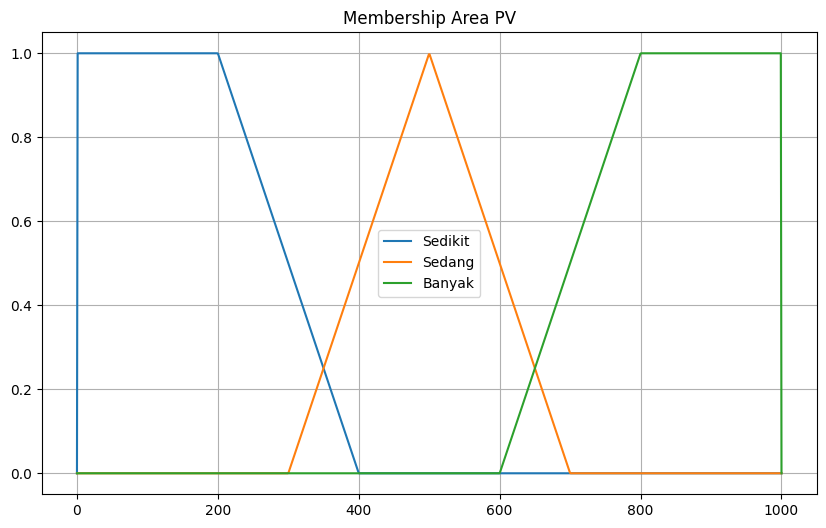

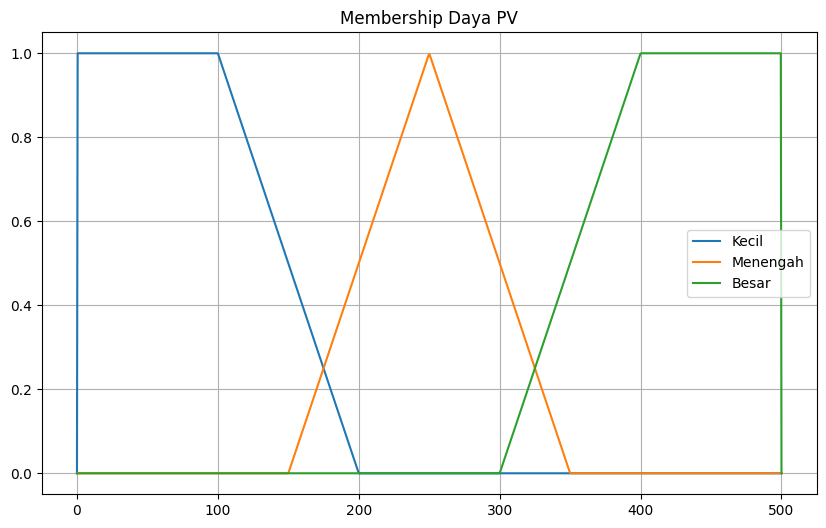

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# MEMBERSHIP FUNCTIONS
# =========================
def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x-a)/(b-a+1e-6), 1), (d-x)/(d-c+1e-6)), 0)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-6), (c-x)/(c-b+1e-6)), 0)

# =========================
# RANGE
# =========================
area_range = np.linspace(0, 1000, 1000)
power_range = np.linspace(0, 500, 1000)

# =========================
# MEMBERSHIP AREA
# =========================
area_sedikit = trapmf(area_range, 0, 0, 200, 400)
area_sedang  = trimf(area_range, 300, 500, 700)
area_banyak  = trapmf(area_range, 600, 800, 1000, 1000)

# =========================
# MEMBERSHIP POWER
# =========================
power_kecil   = trapmf(power_range, 0, 0, 100, 200)
power_menengah= trimf(power_range, 150, 250, 350)
power_besar   = trapmf(power_range, 300, 400, 500, 500)

# =========================
# PLOT MEMBERSHIP
# =========================
plt.figure(figsize=(10,6))

#plt.plot(1,2,1)
plt.plot(area_range, area_sedikit, label='Sedikit')
plt.plot(area_range, area_sedang, label='Sedang')
plt.plot(area_range, area_banyak, label='Banyak')
plt.title("Membership Area PV")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
#plt.plot(1,2,2)
plt.plot(power_range, power_kecil, label='Kecil')
plt.plot(power_range, power_menengah, label='Menengah')
plt.plot(power_range, power_besar, label='Besar')
plt.title("Membership Daya PV")
plt.grid(True)
plt.legend()

plt.show()



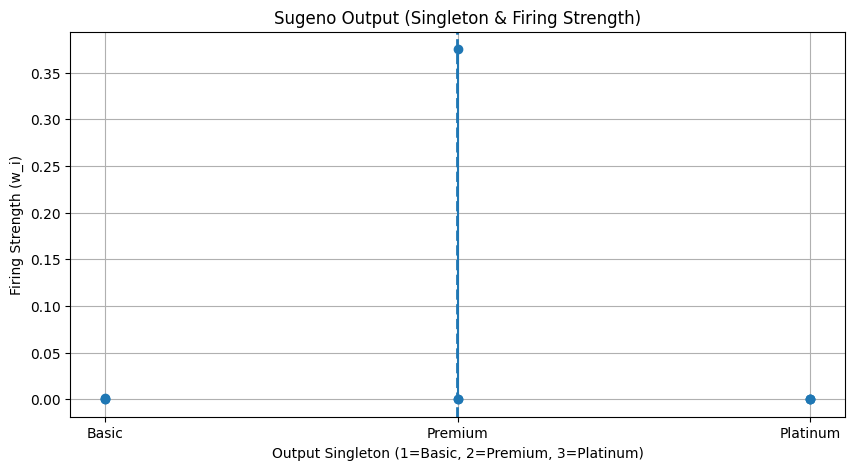

In [ ]:
# =========================
# PLOT OUTPUT (SUGENO)
# =========================
z_values = [r[2] for r in rules]
weights_array = np.array(weights)

plt.figure(figsize=(10,5))

# Stem plot firing strength
plt.stem(z_values, weights_array, basefmt=" ")

# Plot garis hasil defuzzifikasi
plt.axvline(z_final, linestyle='--', linewidth=2)

# Label
plt.title("Sugeno Output (Singleton & Firing Strength)")
plt.xlabel("Output Singleton (1=Basic, 2=Premium, 3=Platinum)")
plt.ylabel("Firing Strength (w_i)")

# Label kategori
plt.xticks([1,2,3], ['Basic','Premium','Platinum'])

plt.grid()
plt.show()

In [ ]:
# =========================
# INPUT USER
# =========================
A = float(input("Masukkan Luas Area PV (0-1000 m2): "))
P = float(input("Masukkan Daya PV (0-500 kW): "))

# =========================
# HITUNG DERAJAT KEANGGOTAAN
# =========================
def interp_membership(x_range, mf, val):
    return np.interp(val, x_range, mf)

μ_A = {
    "sedikit": interp_membership(area_range, area_sedikit, A),
    "sedang":  interp_membership(area_range, area_sedang, A),
    "banyak":  interp_membership(area_range, area_banyak, A)
}

μ_P = {
    "kecil":    interp_membership(power_range, power_kecil, P),
    "menengah": interp_membership(power_range, power_menengah, P),
    "besar":    interp_membership(power_range, power_besar, P)
}

# =========================
# RULE BASE (Sugeno)
# =========================
rules = [
    ("sedikit","kecil",1),
    ("sedikit","menengah",1),
    ("sedikit","besar",2),
    ("sedang","kecil",1),
    ("sedang","menengah",2),
    ("sedang","besar",3),
    ("banyak","kecil",2),
    ("banyak","menengah",3),
    ("banyak","besar",3),
]

# =========================
# INFERENSI
# =========================
weights = []
outputs = []

for area, power, z in rules:
    w = μ_A[area] * μ_P[power]
    weights.append(w)
    outputs.append(w * z)

# =========================
# DEFUZZIFIKASI
# =========================
if sum(weights) == 0:
    z_final = 0
else:
    z_final = sum(outputs) / sum(weights)

# =========================
# INTERPRETASI
# =========================
if z_final <= 1.5:
    kategori = "Basic"
elif z_final <= 2.5:
    kategori = "Premium"
else:
    kategori = "Platinum"

# =========================
# OUTPUT
# =========================
print("\n=== HASIL ===")
print(f"Nilai Defuzzifikasi: {z_final:.3f}")
print(f"Paket Terpilih: {kategori}")

Masukkan Luas Area PV (0-1000 m2): 450
Masukkan Daya PV (0-500 kW): 320

=== HASIL ===
Nilai Defuzzifikasi: 2.400
Paket Terpilih: Premium
